# Global Technology Trends & Developer Insights Analysis
### IBM Data Analyst Capstone Project

**Dataset:** Stack Overflow Developer Survey 2019 (public release)
**Goal:** Identify current technology usage, emerging trends, and future skill demand
among developers, to support hiring, learning, and technology-adoption decisions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("dataset.csv")
print("Shape:", df.shape)
df.head(3)


Shape: (88883, 85)


,Respondent,UndergradMajor,EduOther,OrgSize,DevType,YearsCode,Age1stCode,YearsCodePro,CareerSat,JobSat,...,WelcomeChange,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase
0,1,NaN,"Taught yourself a new language, framework, or ...",NaN,NaN,4,10,NaN,NaN,NaN,...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,14.0,Man,No,Straight / Heterosexual,NaN,No,Appropriate in length,Neither easy nor difficult
1,2,NaN,Taken an online course in programming or softw...,NaN,"Developer, desktop or enterprise applications;...",NaN,17,NaN,NaN,NaN,...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,19.0,Man,No,Straight / Heterosexual,NaN,No,Appropriate in length,Neither easy nor difficult
2,3,Web development or web design,"Taught yourself a new language, framework, or ...",100 to 499 employees,"Designer;Developer, back-end;Developer, front-...",3,22,1,Slightly satisfied,Slightly satisfied,...,Just as welcome now as I felt last year,Tech meetups or events in your area;Courses on...,28.0,Man,No,Straight / Heterosexual,NaN,Yes,Appropriate in length,Neither easy nor difficult


## 1. Data Overview

The raw survey has 88,883 responses and 85 columns. We only need a subset of columns
for this analysis: current/future languages, databases, and a few demographic fields.


In [2]:
cols_needed = [
    "Respondent", "Country", "Age", "EdLevel", "Employment",
    "LanguageWorkedWith", "LanguageDesireNextYear",
    "DatabaseWorkedWith", "DatabaseDesireNextYear",
]
df = df[cols_needed].copy()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 88883 entries, 0 to 88882
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Respondent              88883 non-null  int64  
 1   Country                 88751 non-null  str    
 2   Age                     79210 non-null  float64
 3   EdLevel                 86390 non-null  str    
 4   Employment              87181 non-null  str    
 5   LanguageWorkedWith      87569 non-null  str    
 6   LanguageDesireNextYear  84088 non-null  str    
 7   DatabaseWorkedWith      76026 non-null  str    
 8   DatabaseDesireNextYear  69147 non-null  str    
dtypes: float64(1), int64(1), str(7)
memory usage: 6.1 MB


## 2. Data Cleaning

**Missing values:** Several columns (language/database fields, Age, EdLevel) have
missing values because those survey questions were optional or skipped by respondents
who don't code professionally. We don't impute these — for multi-select "worked with"
fields, a missing value legitimately means "did not answer", so filling it in would
invent data that wasn't collected.

**Age outliers:** The `Age` field is self-reported and contains clearly invalid entries
(e.g., ages of 1 or 99), so we cap it to a plausible working-age range before using it
for demographic analysis.


In [3]:
print("Missing values per column:")
print(df.isna().sum())
print(f"\n{df['Age'].isna().sum()} missing Age values out of {len(df)}")


Missing values per column:
Respondent                    0
Country                     132
Age                        9673
EdLevel                    2493
Employment                 1702
LanguageWorkedWith         1314
LanguageDesireNextYear     4795
DatabaseWorkedWith        12857
DatabaseDesireNextYear    19736
dtype: int64

9673 missing Age values out of 88883


In [4]:
# Age: remove implausible values (self-reported survey noise) rather than imputing
before = df['Age'].notna().sum()
df.loc[(df['Age'] < 10) | (df['Age'] > 75), 'Age'] = np.nan
after = df['Age'].notna().sum()
print(f"Removed {before - after} implausible Age values (kept valid range 10-75)")


Removed 105 implausible Age values (kept valid range 10-75)


## 3. Helper: exploding multi-select fields

Several columns (e.g. `LanguageWorkedWith`) allow multiple selections, stored as a
semicolon-separated string (e.g. `"Python;SQL;JavaScript"`). To count technology usage,
each response needs to be split into one row per technology.


In [5]:
def explode_multiselect(series, top_n=10):
    """Split a semicolon-separated multi-select column and return top_n value counts."""
    exploded = series.dropna().str.split(';').explode().str.strip()
    return exploded.value_counts().head(top_n)

top_current_lang = explode_multiselect(df['LanguageWorkedWith'])
top_future_lang = explode_multiselect(df['LanguageDesireNextYear'])
top_current_lang


LanguageWorkedWith
JavaScript               59219
HTML/CSS                 55466
SQL                      47544
Python                   36443
Java                     35917
Bash/Shell/PowerShell    31991
C#                       27097
PHP                      23030
C++                      20524
TypeScript               18523
Name: count, dtype: int64

## 4. Programming Language Trends: Current Usage vs Future Interest


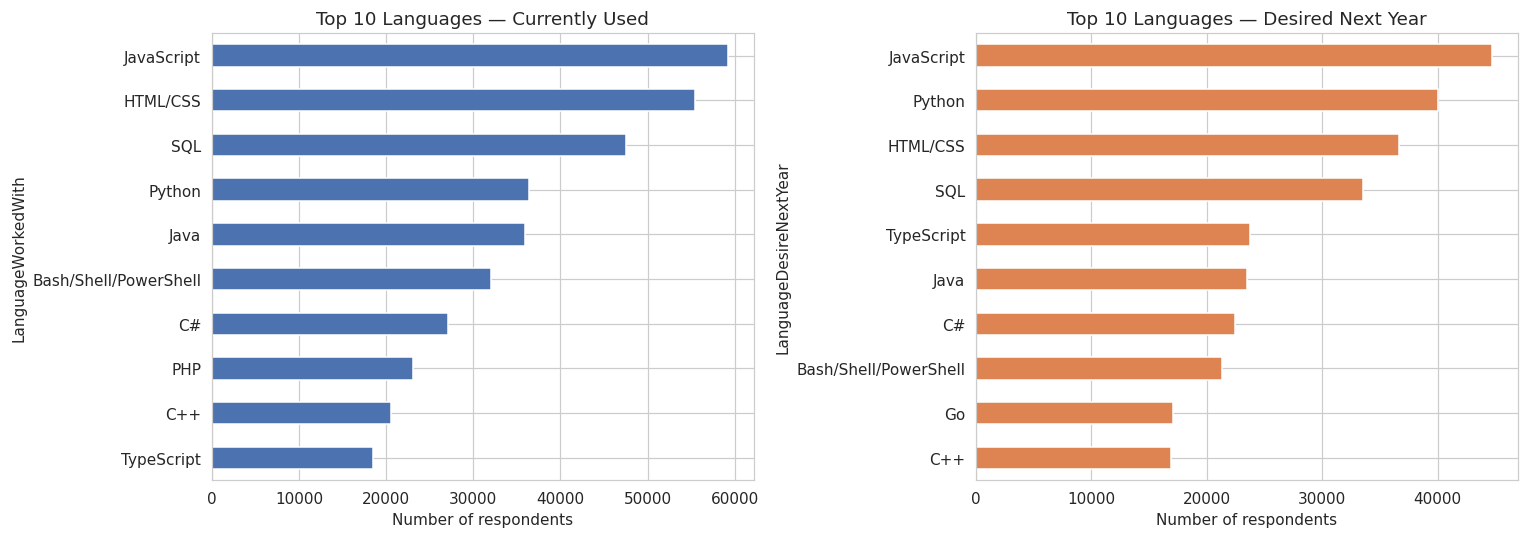

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_current_lang.sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Top 10 Languages — Currently Used")
axes[0].set_xlabel("Number of respondents")

top_future_lang.sort_values().plot.barh(ax=axes[1], color="#DD8452")
axes[1].set_title("Top 10 Languages — Desired Next Year")
axes[1].set_xlabel("Number of respondents")

plt.tight_layout()
plt.savefig("images/dashboard_1_current_usage.png", bbox_inches="tight")
plt.show()


In [7]:
# Growth: rank change between current use and future interest, for languages
# that appear in either top-10 list
langs = sorted(set(top_current_lang.index) | set(top_future_lang.index))
current_full = explode_multiselect(df['LanguageWorkedWith'], top_n=50)
future_full = explode_multiselect(df['LanguageDesireNextYear'], top_n=50)

growth = pd.DataFrame({
    "current_count": current_full.reindex(langs),
    "future_count": future_full.reindex(langs),
}).dropna()
growth["pct_change"] = ((growth["future_count"] - growth["current_count"])
                         / growth["current_count"] * 100).round(1)
growth.sort_values("pct_change", ascending=False)


,current_count,future_count,pct_change
Go,7201,17060,136.9
TypeScript,18523,23720,28.1
Python,36443,40006,9.8
C#,27097,22449,-17.2
C++,20524,16856,-17.9
JavaScript,59219,44739,-24.5
SQL,47544,33566,-29.4
Bash/Shell/PowerShell,31991,21303,-33.4
HTML/CSS,55466,36645,-33.9
Java,35917,23508,-34.5


**Insight:** Python moves from the 4th most-used language today to the 2nd most
*desired* language next year — the clearest sign of rising demand. JavaScript and
HTML/CSS stay dominant but show flat or negative future-interest growth, suggesting
market saturation rather than decline.


## 5. Database Trends


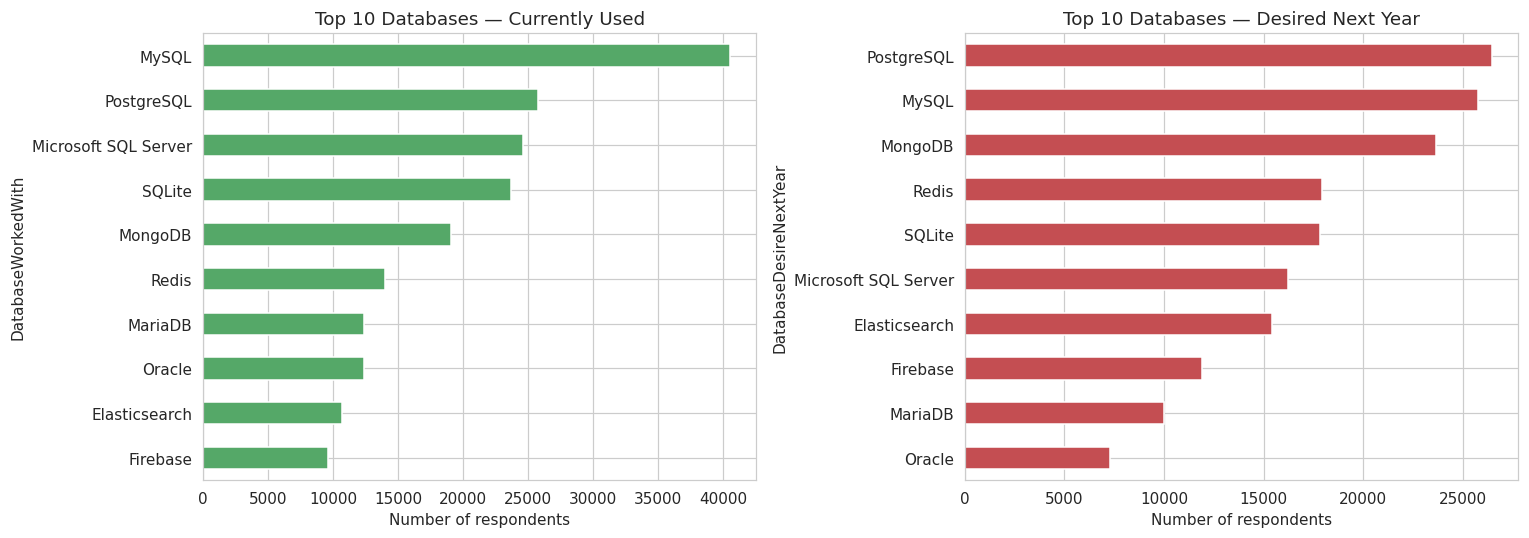

In [8]:
top_current_db = explode_multiselect(df['DatabaseWorkedWith'])
top_future_db = explode_multiselect(df['DatabaseDesireNextYear'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_current_db.sort_values().plot.barh(ax=axes[0], color="#55A868")
axes[0].set_title("Top 10 Databases — Currently Used")
axes[0].set_xlabel("Number of respondents")

top_future_db.sort_values().plot.barh(ax=axes[1], color="#C44E52")
axes[1].set_title("Top 10 Databases — Desired Next Year")
axes[1].set_xlabel("Number of respondents")

plt.tight_layout()
plt.savefig("images/dashboard_2_future_trends.png", bbox_inches="tight")
plt.show()


**Insight:** PostgreSQL is the #1 *desired* database next year despite ranking 2nd
in current usage behind MySQL — a clear signal of a shift toward PostgreSQL. Legacy
enterprise databases (Oracle, Microsoft SQL Server) show comparatively low future demand
relative to their current usage.


## 6. Developer Demographics


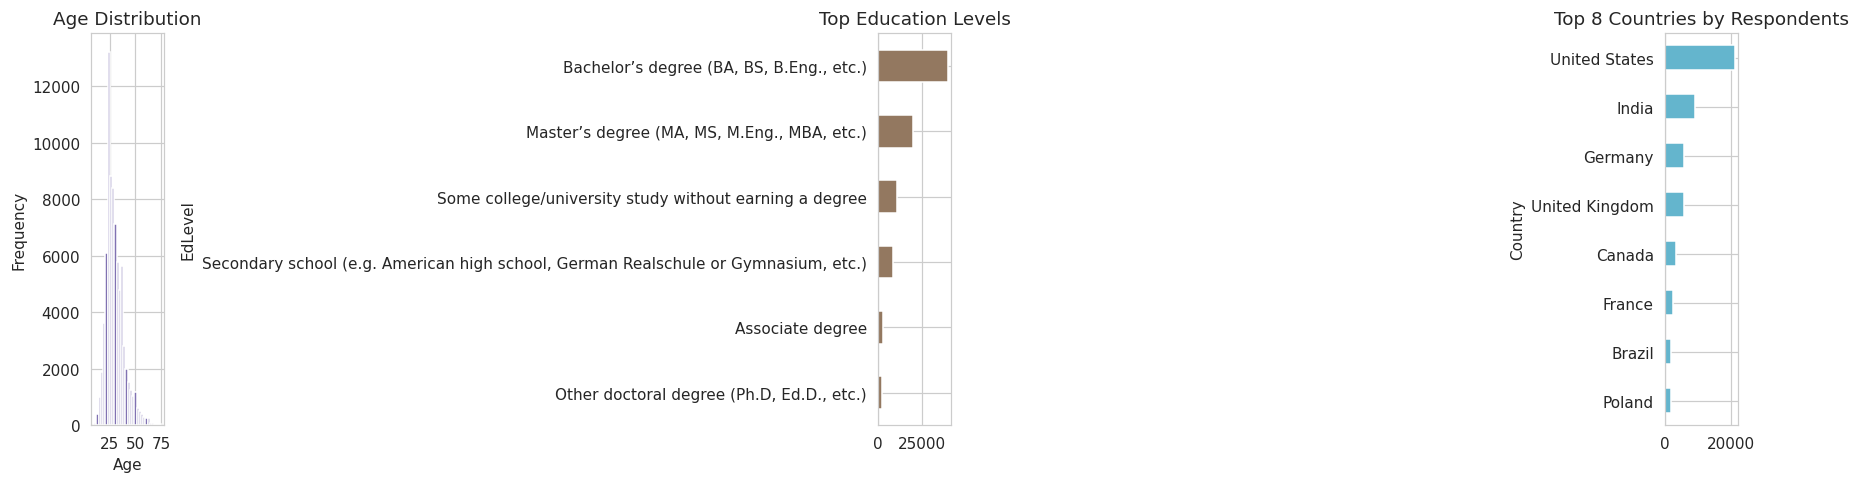

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

df['Age'].dropna().plot.hist(bins=30, ax=axes[0], color="#8172B2")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

df['EdLevel'].value_counts().head(6).sort_values().plot.barh(ax=axes[1], color="#937860")
axes[1].set_title("Top Education Levels")

df['Country'].value_counts().head(8).sort_values().plot.barh(ax=axes[2], color="#64B5CD")
axes[2].set_title("Top 8 Countries by Respondents")

plt.tight_layout()
plt.savefig("images/dashboard_3_demographics.png", bbox_inches="tight")
plt.show()


In [10]:
print(f"Median age: {df['Age'].median():.0f}")
print(f"25-75th percentile range: {df['Age'].quantile(0.25):.0f}-{df['Age'].quantile(0.75):.0f}")
print(f"\nTop 3 education levels cover "
      f"{df['EdLevel'].value_counts().head(3).sum() / df['EdLevel'].notna().sum() * 100:.1f}% of respondents")


Median age: 29
25-75th percentile range: 24-35

Top 3 education levels cover 80.1% of respondents


**Insight:** The typical respondent is in their late 20s to mid-30s (median ~29),
holds a Bachelor's or Master's degree, and the sample is heavily concentrated in the
United States, India, Germany, and the UK — useful context for interpreting all the
trends above as reflecting a Western/English-speaking-leaning developer population,
not a perfectly global one.


## 7. Key Findings Summary

- **JavaScript, HTML/CSS, and SQL** remain the most-used languages overall, but growth
  is flattening.
- **Python** shows the strongest current-to-future growth among mainstream languages,
  consistent with rising demand in data science and automation roles.
- **PostgreSQL** is the standout database gaining developer preference; legacy systems
  (Oracle, MS SQL Server) show comparatively weaker future interest.
- The respondent base skews toward degree-holding developers aged 24-35, concentrated
  in a handful of countries — a limitation to state explicitly when presenting these
  results as "global" trends.

## 8. Limitations

- Self-reported survey data — subject to reporting bias.
- Multi-select fields only tell us adoption breadth, not intensity of use or proficiency.
- Country distribution is skewed toward a few English-speaking/Western markets, so
  regional generalizations should be made cautiously.

## 9. Possible Future Work

- Segment trends by respondent role (e.g., Data Scientist vs Web Developer) using
  `DevType`.
- Bring in salary (`ConvertedComp`) to relate technology choice to compensation.
- Compare this 2019 snapshot against a more recent survey year to see which 2019
  predictions actually played out.
